# New converter with average of slices (mrpro)

In [3]:
import mrpro
from pathlib import Path
import ismrmrd
import xml.dom.minidom as minidom
from typing import Tuple, Optional, List
from concurrent.futures import ProcessPoolExecutor, as_completed
import os, csv, tqdm, h5py   # h5py only used for a fast sanity check
import torch
import h5py, numpy as np

def _to_numpy_complex64(x: torch.Tensor) -> np.ndarray:
    """
    Convert a complex torch tensor (..., H, W) to numpy complex64 with the same shape.
    Accepts torch.complex* dtypes; moves to CPU if needed.
    """
    if not torch.is_complex(x):
        raise TypeError(f"Expected complex tensor, got {x.dtype}")
    return x.detach().cpu().numpy().astype(np.complex64, copy=False)

def _rss_np_from_torch_coils(img_coils: torch.Tensor, coil_dim: int = -4) -> np.ndarray:
    """
    img_coils: torch.complex tensor with dims (..., C, H, W) where C is coil dim (default = -4 if shape is S,C,H,W).
    Returns float32 numpy array with coil-combined RSS magnitude (..., H, W).
    """
    # Ensure coil_dim indexes the coil axis
    if coil_dim != -4:
        img_coils = img_coils.movedim(coil_dim, -4)

    # |img|^2, sum over coils, sqrt
    rss = img_coils.abs().square().sum(dim=-4).sqrt()
    return rss.detach().cpu().numpy().astype(np.float32, copy=False)

def _read_ismrmrd_xml_bytes(ds: ismrmrd.Dataset) -> bytes:
    try:
        xml = ds.read_xml_header()
        return xml.encode("utf-8") if isinstance(xml, str) else xml
    except Exception:
        pass
    try:
        with h5py.File(ds.filename, "r") as f:
            for key in ("ismrmrd_header", "xml", "dataset/xml"):
                if key in f:
                    x = f[key][()]
                    return x if isinstance(x, (bytes, bytearray, np.void)) else str(x).encode("utf-8")
    except Exception:
        pass
    return b""


def ismrmrd_to_fastmri_h5_mrpro(src_path: str, dst_path: str) -> None:
    """
    Read ISMRMRD .h5 using mrpro, optionally average over 'average' index,
    reconstruct coil images with the adjoint FFT, regenerate well-formed Cartesian
    k-space on the header grid with forward FFT, compute RSS, and write a fastMRI-style .h5.
    """
    # 1) Load KData with Cartesian trajectory
    kdata = mrpro.data.KData.from_file(
        src_path,
        mrpro.data.traj_calculators.KTrajectoryCartesian(),
    )
    ds = ismrmrd.Dataset(src_path, "dataset", create_if_needed=False)

    # ---------- NEW: average over 'average' index if present ----------
    data_for_fft = kdata.data  # default: use as-is

    try:
        avg_idx = kdata.header.acq_info.idx.average
        avg_vals = torch.unique(avg_idx)
        n_avg = int(avg_vals.numel())
    except Exception:
        n_avg = 1  # fallback if something weird happens

    if n_avg > 1:
        n_total = data_for_fft.shape[0]
        if n_total % n_avg != 0:
            raise RuntimeError(
                f"Total frames ({n_total}) not divisible by n_avg ({n_avg}) for {src_path}"
            )
        n_slices = n_total // n_avg
        # reshape to (n_avg, n_slices, ...) and average over n_avg
        data_for_fft = data_for_fft.reshape(n_avg, n_slices, *data_for_fft.shape[1:])
        data_for_fft = data_for_fft.mean(dim=0)  # (n_slices, C, 1, ky, kx)
    # ---------------------------------------------------------------

    # 2) Define FFT operator on spatial dims (-2,-1)
    fft_op = mrpro.operators.FastFourierOp(
        dim=(-2, -1),
        recon_matrix=kdata.header.recon_matrix,
        encoding_matrix=kdata.header.encoding_matrix,
    )

    # 3) Adjoint: k-space -> coil images on recon grid
    (img_coils,) = fft_op.adjoint(data_for_fft)  # complex torch tensor, shape ~ (S, C, rec_y, rec_x)

    # 4) Forward: coil images -> Cartesian k-space on encoding grid (ny=enc_y, nx=enc_x)
    (kspace_coils,) = fft_op.forward(img_coils)  # complex torch tensor, shape ~ (S, C, enc_y, enc_x)

    # 5) Prepare arrays for saving
    kspace_np = _to_numpy_complex64(kspace_coils)               # (S, C, enc_y, enc_x) complex64
    rss_np    = _rss_np_from_torch_coils(img_coils, coil_dim=1) # (S, rec_y, rec_x) float32

    def _as_int(v):
        # Handles python ints, numpy ints, and 0-d torch tensors
        try:
            if isinstance(v, torch.Tensor):
                return int(v.item())
        except Exception:
            pass
        try:
            return int(v)
        except Exception:
            return int(str(v))

    # Sizes from mrpro header (SpatialDimension[z,y,x])
    enc = kdata.header.encoding_matrix   # SpatialDimension[int]
    rec = kdata.header.recon_matrix      # SpatialDimension[int]

    enc_y, enc_x = _as_int(enc.y), _as_int(enc.x)
    rec_y, rec_x = _as_int(rec.y), _as_int(rec.x)

    # fastMRI-style padding along readout (x)
    pad_total = max(0, enc_x - rec_x)
    pad_left  = pad_total // 2
    pad_right = pad_left + rec_x

    # 7) Read raw XML header bytes
    xml_bytes = _read_ismrmrd_xml_bytes(ds)
    dom = None
    if xml_bytes:
        try:
            dom = minidom.parseString(xml_bytes)
        except Exception:
            dom = None

    # 8) Write fastMRI-style file
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with h5py.File(dst_path, "w") as f:
        # fastMRI expects 'kspace' as complex64 with shape (S, C, H, W)
        f.create_dataset("kspace", data=kspace_np.squeeze())          # complex64
        f.create_dataset("reconstruction_rss", data=rss_np.squeeze()) # float32
        f.create_dataset("ismrmrd_header", data=np.void(xml_bytes))   # raw XML (if available)

        S, C, H, W = kspace_np.squeeze().shape
        f.attrs["shape_sc_hw"] = np.array([S, C, H, W], dtype=np.int64)

        # Recon size matches RSS shape (rec_y, rec_x)
        f.attrs["recon_size"] = np.array([rec_y, rec_x], dtype=np.int64)

        # Padding along readout (x)
        f.attrs["padding_left"]  = np.int64(pad_left)
        f.attrs["padding_right"] = np.int64(pad_right)
        f.attrs["padding"]       = np.array([pad_left, pad_right], dtype=np.int64)

        f.attrs["max"] = rss_np.max()


    # Close ISMRMRD handle
    try:
        ds.close()
    except Exception:
        pass


# --- quick sanity check so we don't schedule obviously broken files ---
def _validate_src(src: str) -> Optional[str]:
    """Return None if OK, else an error string describing what's wrong."""
    try:
        with h5py.File(src, "r") as f:
            # Touch minimal metadata/dataset to force basic HDF5 parsing
            list(f.keys())
        return None
    except Exception as e:
        return f"InvalidH5: {type(e).__name__}: {e}"

import warnings
def _convert_one(arg: Tuple[str, str]) -> Tuple[str, Optional[str]]:
    """Worker: returns (src_path, error_msg_or_None)."""
    src, dst = arg
    try:
        os.makedirs(os.path.dirname(dst), exist_ok=True)

        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            ismrmrd_to_fastmri_h5_mrpro(src, dst)

        for warn in w:
            msg = str(warn.message)
            cat = warn.category

            if (
                cat is DeprecationWarning
                and "`product` is deprecated as of NumPy 1.25.0" in msg
            ):
                continue
            print(f"[WARNING] {src}: {cat.__name__}: {msg}")
        return (src, None)

    except Exception as e:
        return (src, f"{type(e).__name__}: {e}")


def convert_folder_mp(
    src_folder: str,
    dst_folder: str,
    pattern: str = "*.h5",
    max_workers: Optional[int] = None,
    skip_existing: bool = True,
    error_log_csv: Optional[str] = None,
) -> List[Tuple[str, str]]:
    """Returns list of (src, error) for any failures."""
    srcp = Path(src_folder)
    dstp = Path(dst_folder)
    files = sorted(srcp.glob(pattern))

    # Prepare tasks (and pre-filter obviously broken files)
    tasks = []
    errors: List[Tuple[str, str]] = []

    for sp in files:
        dp = dstp / sp.name
        if skip_existing and dp.exists():
            continue

        err = _validate_src(str(sp))
        if err is not None:
            errors.append((str(sp), err))
            continue  # don't even schedule this one

        tasks.append((str(sp), str(dp)))

    if not tasks and not errors:
        print("Nothing to do (all done or no matches).")
        return []

    if max_workers is None:
        max_workers = max(1, min(os.cpu_count() or 1, 8))

    print(f"Converting {len(tasks)} valid files with {max_workers} workers…")
    # h5py is NOT thread-safe → use processes
    fut_to_src = {}
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        for t in tasks:
            print(t)
            fut = ex.submit(_convert_one, t)
            fut_to_src[fut] = t[0]  # remember src for this future

        for fut in tqdm.tqdm(as_completed(fut_to_src), total=len(fut_to_src), desc="Converting"):
            src = fut_to_src[fut]
            try:
                src_ret, err = fut.result()
                if err:
                    print(f"- Error converting {src_ret}: {err}")
                    errors.append((src_ret, err))
            except Exception as e:
                # covers worker crashes (e.g., segfault inside native libs)
                errors.append((src, f"WorkerCrash: {type(e).__name__}: {e}"))

    if errors:
        print("\n=== Errors ===")
        for src, err in errors[:25]:
            print(f"- {src}: {err}")
        if len(errors) > 25:
            print(f"... and {len(errors)-25} more")

        if error_log_csv:
            os.makedirs(os.path.dirname(error_log_csv) or ".", exist_ok=True)
            with open(error_log_csv, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(["src", "error"])
                w.writerows(errors)
            print(f"\nSaved error log to: {error_log_csv}")
    else:
        print("All files converted successfully ✅")

    return errors

convert_folder_mp(
    src_folder='../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5',
    dst_folder='../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro',
    pattern="*.h5",
    max_workers=16,     # auto
    skip_existing=True,   # don’t redo work
)
# files = [ "meas_MID00213_FID123579_SAG_T1.h5",
#    "meas_MID00217_FID128725_SAG_T2.h5",
#    "meas_MID00260_FID113230_LT_COR_T2_OBL.h5",
#    "meas_MID00265_FID112242_COR_T1.h5",
#    "meas_MID00266_FID110699_COR_T1.h5",]
  
# src_folder = Path('../../../../../data/datasets/msk_mri/h5')
# dest_folder = Path('../../../../../data/datasets/msk_mri/varnet_mrpro')
# for file in files:
#     src_path = src_folder / file
#     print(src_path)
#     ismrmrd_to_fastmri_h5_mrpro(str(src_path), str(dest_folder / src_path.name))

    

Converting 5 valid files with 16 workers…
('../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00057_FID141038_COR_PD_FS.h5', '../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro/meas_MID00057_FID141038_COR_PD_FS.h5')


('../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00107_FID162293_AX_T2_TGSE.h5', '../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro/meas_MID00107_FID162293_AX_T2_TGSE.h5')
('../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00167_FID160384_SAG_T1_IN_OUT_PHASE_DIXON_WEAK.h5', '../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro/meas_MID00167_FID160384_SAG_T1_IN_OUT_PHASE_DIXON_WEAK.h5')
('../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00269_FID162925_RT_RADIAL_LOC_AX.h5', '../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro/meas_MID00269_FID162925_RT_RADIAL_LOC_AX.h5')
('../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00333_FID153287_SAG_T1.h5', '../../../../../data/datasets/msk_mri_batch_2_samples_h5/varnet_mrpro/meas_MID00333_FID153287_SAG_T1.h5')


Converting:  80%|████████  | 4/5 [00:28<00:08,  8.61s/it]

[WARNING] ../../../../../data/datasets/msk_mri_batch_2_samples_h5/h5/meas_MID00107_FID162293_AX_T2_TGSE.h5: UserWarning: There are different numbers of acquisistions indifferent combinations of labels {"/".join(OTHER_LABELS)}: 
Found [169, 179, 182]. 
The data will be reshaped to (acquisitions, coils, 1, 1, k0). 
This needs to be adjusted be reshaping for a successful reconstruction. 
If unintenional, this might be caused by wrong labels in the ismrmrd file or a wrong flag filter. 
To fix, it might be necessary to subset the data such that it can be reshaped to (other, coils, k2, k1, k0), or indexes needs to be fixed. 
After fixing the issue, call reshape_by_idx and consider recalculating the trajectory.


Converting: 100%|██████████| 5/5 [07:26<00:00, 89.30s/it] 

All files converted successfully ✅


[]

# Check if "max" exists as it causes problems

In [2]:
# --- Config ---
ROOT = '../../../../../data/datasets/msk_mri_h5/varnet_mrpro'
PATTERN = "*.h5"           # e.g., "*.h5" or "*.hdf5"
WORKERS = 8                # parallel workers (>=1)

# --- Code ---
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
import h5py, sys, os

def _check_one(path_str: str):
    """Return (path, has_attr, error_str_or_None)."""
    try:
        with h5py.File(path_str, "r") as f:
            has_attr = "max" in f.attrs
        return (path_str, has_attr, None)
    except Exception as e:
        return (path_str, False, f"{type(e).__name__}: {e}")

root = Path(os.path.expanduser(ROOT)).resolve()
files = sorted(root.rglob(PATTERN))

if not files:
    print(f"No files found under {root} matching {PATTERN}.")
else:
    results = []
    with ProcessPoolExecutor(max_workers=WORKERS) as ex:
        futs = [ex.submit(_check_one, str(p)) for p in files]
        for fut in as_completed(futs):
            results.append(fut.result())

    # Aggregate
    missing = [p for (p, ok, err) in results if (err is None and not ok)]
    errors  = [(p, err) for (p, ok, err) in results if err is not None]
    present = sum(1 for (_, ok, err) in results if (err is None and ok))

    # Print reports
    if missing:
        print("\nFiles missing f.attrs['max']:\n" + "-"*32)
        for p in sorted(missing):
            print(p)
    else:
        print("\nAll scanned files have f.attrs['max'].")

    if errors:
        print("\nFiles that could not be read:\n" + "-"*32)
        for p, e in sorted(errors):
            print(f"{p}  |  {e}")

    total = len(results)
    print("\nSummary")
    print("-------")
    print(f"Scanned    : {total}")
    print(f"Have 'max' : {present}")
    print(f"Missing    : {len(missing)}")
    print(f"Errors     : {len(errors)}")

    # Keep handy for downstream cells
    CHECK_RESULTS = results
    MISSING_MAX   = missing
    ERROR_FILES   = errors



All scanned files have f.attrs['max'].

Summary
-------
Scanned    : 3116
Have 'max' : 3116
Missing    : 0
Errors     : 0


# uses mrpro to convert

In [ ]:
import os
import h5py
import numpy as np

import mrpro
import torch
from pathlib import Path
import tqdm
import ismrmrd
import xml.dom.minidom as minidom

from typing import Tuple, Optional, List
from concurrent.futures import ProcessPoolExecutor, as_completed
import os, csv, tqdm, h5py   # h5py only used for a fast sanity check

def _to_numpy_complex64(x: torch.Tensor) -> np.ndarray:
    """
    Convert a complex torch tensor (..., H, W) to numpy complex64 with the same shape.
    Accepts torch.complex* dtypes; moves to CPU if needed.
    """
    if not torch.is_complex(x):
        raise TypeError(f"Expected complex tensor, got {x.dtype}")
    return x.detach().cpu().numpy().astype(np.complex64, copy=False)

def _rss_np_from_torch_coils(img_coils: torch.Tensor, coil_dim: int = -4) -> np.ndarray:
    """
    img_coils: torch.complex tensor with dims (..., C, H, W) where C is coil dim (default = -4 if shape is S,C,H,W).
    Returns float32 numpy array with coil-combined RSS magnitude (..., H, W).
    """
    # Ensure coil_dim indexes the coil axis
    if coil_dim != -4:
        img_coils = img_coils.movedim(coil_dim, -4)

    # |img|^2, sum over coils, sqrt
    rss = img_coils.abs().square().sum(dim=-4).sqrt()
    return rss.detach().cpu().numpy().astype(np.float32, copy=False)

import h5py, numpy as np

def _read_ismrmrd_xml_bytes(ds: ismrmrd.Dataset) -> bytes:
    try:
        xml = ds.read_xml_header()
        return xml.encode("utf-8") if isinstance(xml, str) else xml
    except Exception:
        pass
    try:
        with h5py.File(ds.filename, "r") as f:
            for key in ("ismrmrd_header", "xml", "dataset/xml"):
                if key in f:
                    x = f[key][()]
                    return x if isinstance(x, (bytes, bytearray, np.void)) else str(x).encode("utf-8")
    except Exception:
        pass
    return b""


def ismrmrd_to_fastmri_h5_mrpro(src_path: str, dst_path: str) -> None:
    """
    Read ISMRMRD .h5 using mrpro, reconstruct coil images with the adjoint FFT,
    regenerate well-formed Cartesian k-space on the header grid with forward FFT,
    compute RSS, and write a fastMRI-style .h5.
    """
    # 1) Load KData with Cartesian trajectory
    kdata = mrpro.data.KData.from_file(
        src_path,
        mrpro.data.traj_calculators.KTrajectoryCartesian(),
    )
    ds = ismrmrd.Dataset(src_path, "dataset", create_if_needed=False)

    # 2) Define FFT operator on spatial dims (-2,-1)
    fft_op = mrpro.operators.FastFourierOp(
        dim=(-2, -1),
        recon_matrix=kdata.header.recon_matrix,
        encoding_matrix=kdata.header.encoding_matrix,
    )

    # 3) Adjoint: k-space (possibly non-uniformly packed lines) -> coil images on recon grid
    # Returns a 1-tuple
    (img_coils,) = fft_op.adjoint(kdata.data)  # complex torch tensor, shape ~ (S, C, rec_y, rec_x)

    # 4) Forward: coil images -> Cartesian k-space on encoding grid (ny=enc_y, nx=enc_x)
    # This gives you "the correct k-space" aligned with header encoding_matrix
    (kspace_coils,) = fft_op.forward(img_coils)  # complex torch tensor, shape ~ (S, C, enc_y, enc_x)

    # 5) Prepare arrays for saving
    # Shapes
    #   kspace: (S, C, H, W) where H=enc_y, W=enc_x
    #   rss:    (S, rec_y, rec_x)
    kspace_np = _to_numpy_complex64(kspace_coils)                 # (S, C, enc_y, enc_x) complex64
    rss_np    = _rss_np_from_torch_coils(img_coils, coil_dim=1)   # (S, rec_y, rec_x) float32
    #print(f"Converted kspace shape: {kspace_np.shape}, rss shape: {rss_np.shape}")
    def _as_int(v):
    # Handles python ints, numpy ints, and 0-d torch tensors
        try:
            # torch scalar?
            import torch
            if isinstance(v, torch.Tensor):
                return int(v.item())
        except Exception:
            pass
        try:
            return int(v)
        except Exception:
            # last resort: strings etc.
            return int(str(v))

    # Sizes from mrpro header (SpatialDimension[z,y,x])
    enc = kdata.header.encoding_matrix   # SpatialDimension[int]
    rec = kdata.header.recon_matrix      # SpatialDimension[int]

    enc_y, enc_x = _as_int(enc.y), _as_int(enc.x)
    rec_y, rec_x = _as_int(rec.y), _as_int(rec.x)

    # fastMRI-style padding along readout (x)
    pad_total = max(0, enc_x - rec_x)
    pad_left  = pad_total // 2
    pad_right = pad_left + rec_x

    # 7) Read raw XML header bytes for provenance (optional but nice to have)
    #    mrpro exposes the parsed header; if you also want the original XML bytes, try to fetch them here.
    #    If not easily available, store an empty blob or a small marker.

    xml_bytes = _read_ismrmrd_xml_bytes(ds)
    dom = None
    if xml_bytes:
        try: dom = minidom.parseString(xml_bytes)
        except Exception: dom = None

    # 8) Write fastMRI-style file
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    with h5py.File(dst_path, "w") as f:
        # fastMRI expects 'kspace' as complex64 with shape (S, C, H, W)
        f.create_dataset("kspace", data=kspace_np.squeeze())                       # complex64
        f.create_dataset("reconstruction_rss", data=rss_np.squeeze())              # float32
        f.create_dataset("ismrmrd_header", data=np.void(xml_bytes))      # raw XML (if available)

        S, C, H, W = kspace_np.squeeze().shape
        f.attrs["shape_sc_hw"] = np.array([S, C, H, W], dtype=np.int64)

        # Recon size matches RSS shape (rec_y, rec_x)
        f.attrs["recon_size"] = np.array([rec_y, rec_x], dtype=np.int64)

        # Padding along readout (x)
        f.attrs["padding_left"]  = np.int64(pad_left)
        f.attrs["padding_right"] = np.int64(pad_right)
        f.attrs["padding"]       = np.array([pad_left, pad_right], dtype=np.int64)

        f.attrs["max"] = rss_np.max()

# --- quick sanity check so we don't schedule obviously broken files ---
def _validate_src(src: str) -> Optional[str]:
    """Return None if OK, else an error string describing what's wrong."""
    try:
        with h5py.File(src, "r") as f:
            # Touch minimal metadata/dataset to force basic HDF5 parsing
            list(f.keys())
        return None
    except Exception as e:
        return f"InvalidH5: {type(e).__name__}: {e}"

def _convert_one(arg: Tuple[str, str]) -> Tuple[str, Optional[str]]:
    """Worker: returns (src_path, error_msg_or_None)."""
    src, dst = arg
    try:
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        # IMPORTANT: ismrmrd_to_fastmri_h5_mrpro must open/close files inside (no globals)
        ismrmrd_to_fastmri_h5_mrpro(src, dst)
        return (src, None)
    except Exception as e:
        return (src, f"{type(e).__name__}: {e}")

def convert_folder_mp(
    src_folder: str,
    dst_folder: str,
    pattern: str = "*.h5",
    max_workers: Optional[int] = None,
    skip_existing: bool = True,
    error_log_csv: Optional[str] = None,
) -> List[Tuple[str, str]]:
    """Returns list of (src, error) for any failures."""
    srcp = Path(src_folder)
    dstp = Path(dst_folder)
    files = sorted(srcp.glob(pattern))

    # Prepare tasks (and pre-filter obviously broken files)
    tasks = []
    errors: List[Tuple[str, str]] = []

    for sp in files:
        dp = dstp / sp.name
        if skip_existing and dp.exists():
            continue

        err = _validate_src(str(sp))
        if err is not None:
            errors.append((str(sp), err))
            continue  # don't even schedule this one

        tasks.append((str(sp), str(dp)))

    if not tasks and not errors:
        print("Nothing to do (all done or no matches).")
        return []

    if max_workers is None:
        max_workers = max(1, min(os.cpu_count() or 1, 8))

    print(f"Converting {len(tasks)} valid files with {max_workers} workers…")
    # h5py is NOT thread-safe → use processes
    fut_to_src = {}
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        for t in tasks:
            fut = ex.submit(_convert_one, t)
            fut_to_src[fut] = t[0]  # remember src for this future

        for fut in tqdm.tqdm(as_completed(fut_to_src), total=len(fut_to_src), desc="Converting"):
            src = fut_to_src[fut]
            try:
                src_ret, err = fut.result()
                if err:
                    errors.append((src_ret, err))
            except Exception as e:
                # covers worker crashes (e.g., segfault inside native libs)
                errors.append((src, f"WorkerCrash: {type(e).__name__}: {e}"))

    if errors:
        print("\n=== Errors ===")
        for src, err in errors[:25]:
            print(f"- {src}: {err}")
        if len(errors) > 25:
            print(f"... and {len(errors)-25} more")

        if error_log_csv:
            os.makedirs(os.path.dirname(error_log_csv) or ".", exist_ok=True)
            with open(error_log_csv, "w", newline="") as f:
                w = csv.writer(f)
                w.writerow(["src", "error"])
                w.writerows(errors)
            print(f"\nSaved error log to: {error_log_csv}")
    else:
        print("All files converted successfully ✅")

    return errors

convert_folder_mp(
    src_folder='../../../../../data/datasets/msk_mri_h5/val_new_metadata',
    dst_folder='../../../../../data/datasets/msk_mri_h5/val_varnet_mrpro',
    pattern="*.h5",
    max_workers=8,     # auto
    skip_existing=True,   # don’t redo work
)
  


Converting 392 valid files with 8 workers…


Converting:   0%|          | 0/392 [05:44<?, ?it/s]


# Check files are not broken

In [ ]:
from fastmri.data import SliceDataset
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri.data import transforms as T
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

data_path = '../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro'
mask_func = create_mask_for_mask_type("equispaced", [0.08], [4])
data_transform = T.VarNetDataTransform(mask_func=mask_func)
dataset = SliceDataset(root=data_path, transform=data_transform, challenge="multicoil")
dataloader = torch.utils.data.DataLoader(dataset, num_workers=8)
broken_files = set()

from tqdm import tqdm

broken_files = set()

for idx in tqdm(range(0, len(dataloader)), desc="Checking slices"):
    try:
        sample = dataset[idx]
    except Exception as e:
        fname = getattr(sample, "fname", f"idx_{idx}")
        if fname not in broken_files:
            print(f"Broken file at index {idx}: {fname} ({e})")
            broken_files.add(fname)

if not broken_files:
    print("No broken files found.")
else:
    print(f"Broken files: {broken_files}")

../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00015_FID117913_COR_T2.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00016_FID118817_COR_T2.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00016_FID120712_COR_T2.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00017_FID116488_RT_3_PLANE_UOF.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00017_FID118818_SAG_T2.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00017_FID126574_RT_3_PLANE_UOF.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00018_FID110986_COR_PD_FS.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00018_FID111995_COR_PD_FS.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00018_FID117916_SAG_T2.h5
../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00018_FID118819_AXIAL_T2.h5
../../../../../data/datasets/msk_mri_h5/train_

Checking slices:   0%|          | 139/51955 [00:07<48:53, 17.66it/s] 


KeyboardInterrupt: 

In [ ]:
broken_files

In [7]:
import h5py
fname = "../../../../../data/datasets/msk_mri_h5/train_varnet_mrpro/meas_MID00217_FID128725_SAG_T2.h5"
with h5py.File(fname, "r") as hf:
    print("hello")

OSError: Unable to open file (bad object header version number)

# test masking of varnet

meas_MID00147_FID116144_RT_AX_T1.h5


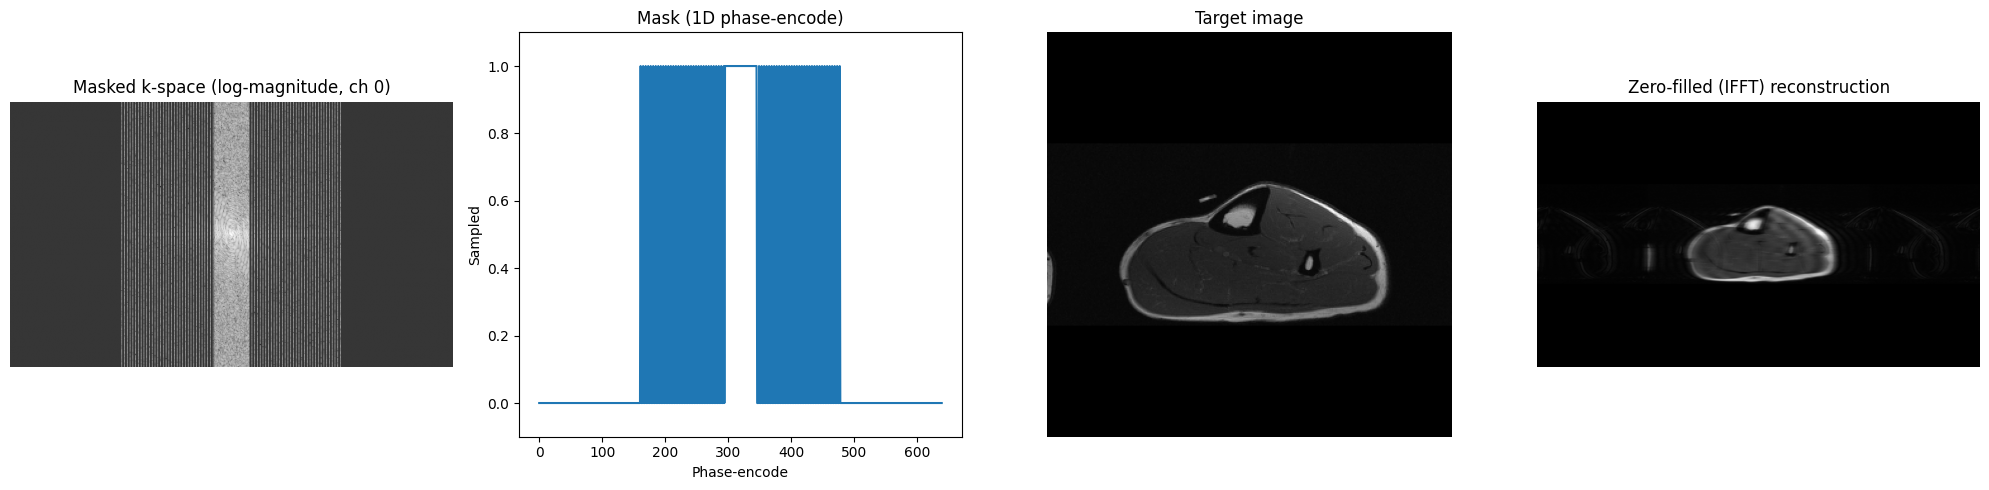

In [4]:
from fastmri.data import SliceDataset
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri.data import transforms as T
data_path = '../../../../../data/datasets/msk_mri_h5/varnet_mrpro'
#data_path = './fast_mri_samples'
mask_func = create_mask_for_mask_type("equispaced", [0.08], [4])
data_transform = T.VarNetDataTransform(mask_func=mask_func)
#data_transform = VarNetDataTransformAutoMask(mask_func=mask_func)
dataset = SliceDataset(root=data_path, transform=data_transform, challenge="multicoil")

# Plot masked k-space, mask, target image, and zero-filled (IFFT) reconstruction for the first sample
import matplotlib.pyplot as plt
import torch
import numpy as np

#sample = dataset_new_test[58]
#sample= dataset_old_test[504]
sample = dataset[21843]
print(sample.fname)


masked_kspace = sample.masked_kspace # torch tensor, shape: (num_coils, height, width, 2)
mask = sample.mask.numpy()
target = sample.target.numpy()

# For visualization, take the first channel of masked_kspace and show log-magnitude
masked_kspace_np = masked_kspace.numpy() if hasattr(masked_kspace, 'numpy') else masked_kspace
masked_kspace_mag = np.log(np.abs(masked_kspace_np[0, ..., 0] + 1e-9))
if masked_kspace.shape[-1] == 2:
    masked_kspace_cplx = torch.view_as_complex(masked_kspace)
else:
    masked_kspace_cplx = masked_kspace
img_coils = torch.fft.ifftshift(torch.fft.ifft2(torch.fft.fftshift(masked_kspace_cplx, dim=(-2, -1)), norm="ortho"), dim=(-2, -1))
img_rss = torch.sqrt((img_coils.abs() ** 2).sum(dim=0))
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(masked_kspace_mag, cmap='gray')
axs[0].set_title('Masked k-space (log-magnitude, ch 0)')
axs[0].axis('off')

# Visualize the 1D mask as a line plot
axs[1].plot(np.squeeze(mask))
axs[1].set_title('Mask (1D phase-encode)')
axs[1].set_ylim(-0.1, 1.1)
axs[1].set_xlabel('Phase-encode')
axs[1].set_ylabel('Sampled')

axs[2].imshow(target, cmap='gray')
axs[2].set_title('Target image')
axs[2].axis('off')

axs[3].imshow(img_rss.numpy(), cmap='gray')
axs[3].set_title('Zero-filled (IFFT) reconstruction')
axs[3].axis('off')

plt.tight_layout()
plt.show()